In [1]:
import sys
sys.path.append("../../src")

import numpy as np
from numba import njit
from scipy.stats import ortho_group
from tqdm import tqdm
import matplotlib.pyplot as plt

from python_utils.visualization_utils import display_matrix, plot_bss_comparison, subplot_1D_signals
from bss.bss_utils import generate_uncorrelated_uniform_sources, addWGN, ProjectRowstoL1NormBall
from bss.PredictiveDecorrBSS import PredictiveDecorrBSS

# Generate Sources and Mix Them (Underdetermined 4 by 5 case, Bernoulli-Sparse Sources)

In [2]:
# np.random.seed(400)
seed = 7  # fixed seed with a favorable underdetermined mixing (some sources recoverable)
np.random.seed(seed)
print("seed is ", seed)
N = 100000
NumberofSources = 5
NumberofMixtures = NumberofSources - 1  # underdetermined: fewer mixtures than sources

# Bernoulli-sparse sources: each source is active (nonzero) with probability p_active,
# with a uniform amplitude when active.
p_active = 0.2
S = np.random.uniform(-1, 1, (NumberofSources, N)) * (np.random.rand(NumberofSources, N) < p_active)
print("The following is the correlation matrix of sources")
display_matrix(np.corrcoef(S))

# # Generate Mxr random mixing from i.i.d N(0,1)
A = np.random.randn(NumberofMixtures, NumberofSources) # Random Gaussian mixing matrix
# A = ortho_group.rvs(dim=NumberofSources) # Random orthogonal mixing matrix
X_noNoise = np.dot(A, S)


SNR = 30
X = addWGN(X_noNoise, SNR)

SNRinp = 10 * np.log10(
    np.sum(np.mean(X_noNoise ** 2, axis=1))
    / np.sum(np.mean((X_noNoise - X)**2, axis=1))
)
print("The following is the mixture matrix A")
display_matrix(A)
print("Input SNR is : {}".format(SNRinp))
S.var(1), X.var(1)

seed is  7
The following is the correlation matrix of sources


<IPython.core.display.Math object>

The following is the mixture matrix A


<IPython.core.display.Math object>

Input SNR is : 29.996372499395825


(array([0.06683397, 0.06568599, 0.06649067, 0.06685132, 0.06679353]),
 array([0.55311086, 0.23818973, 0.26908697, 0.66902786]))

# Hyperparameters

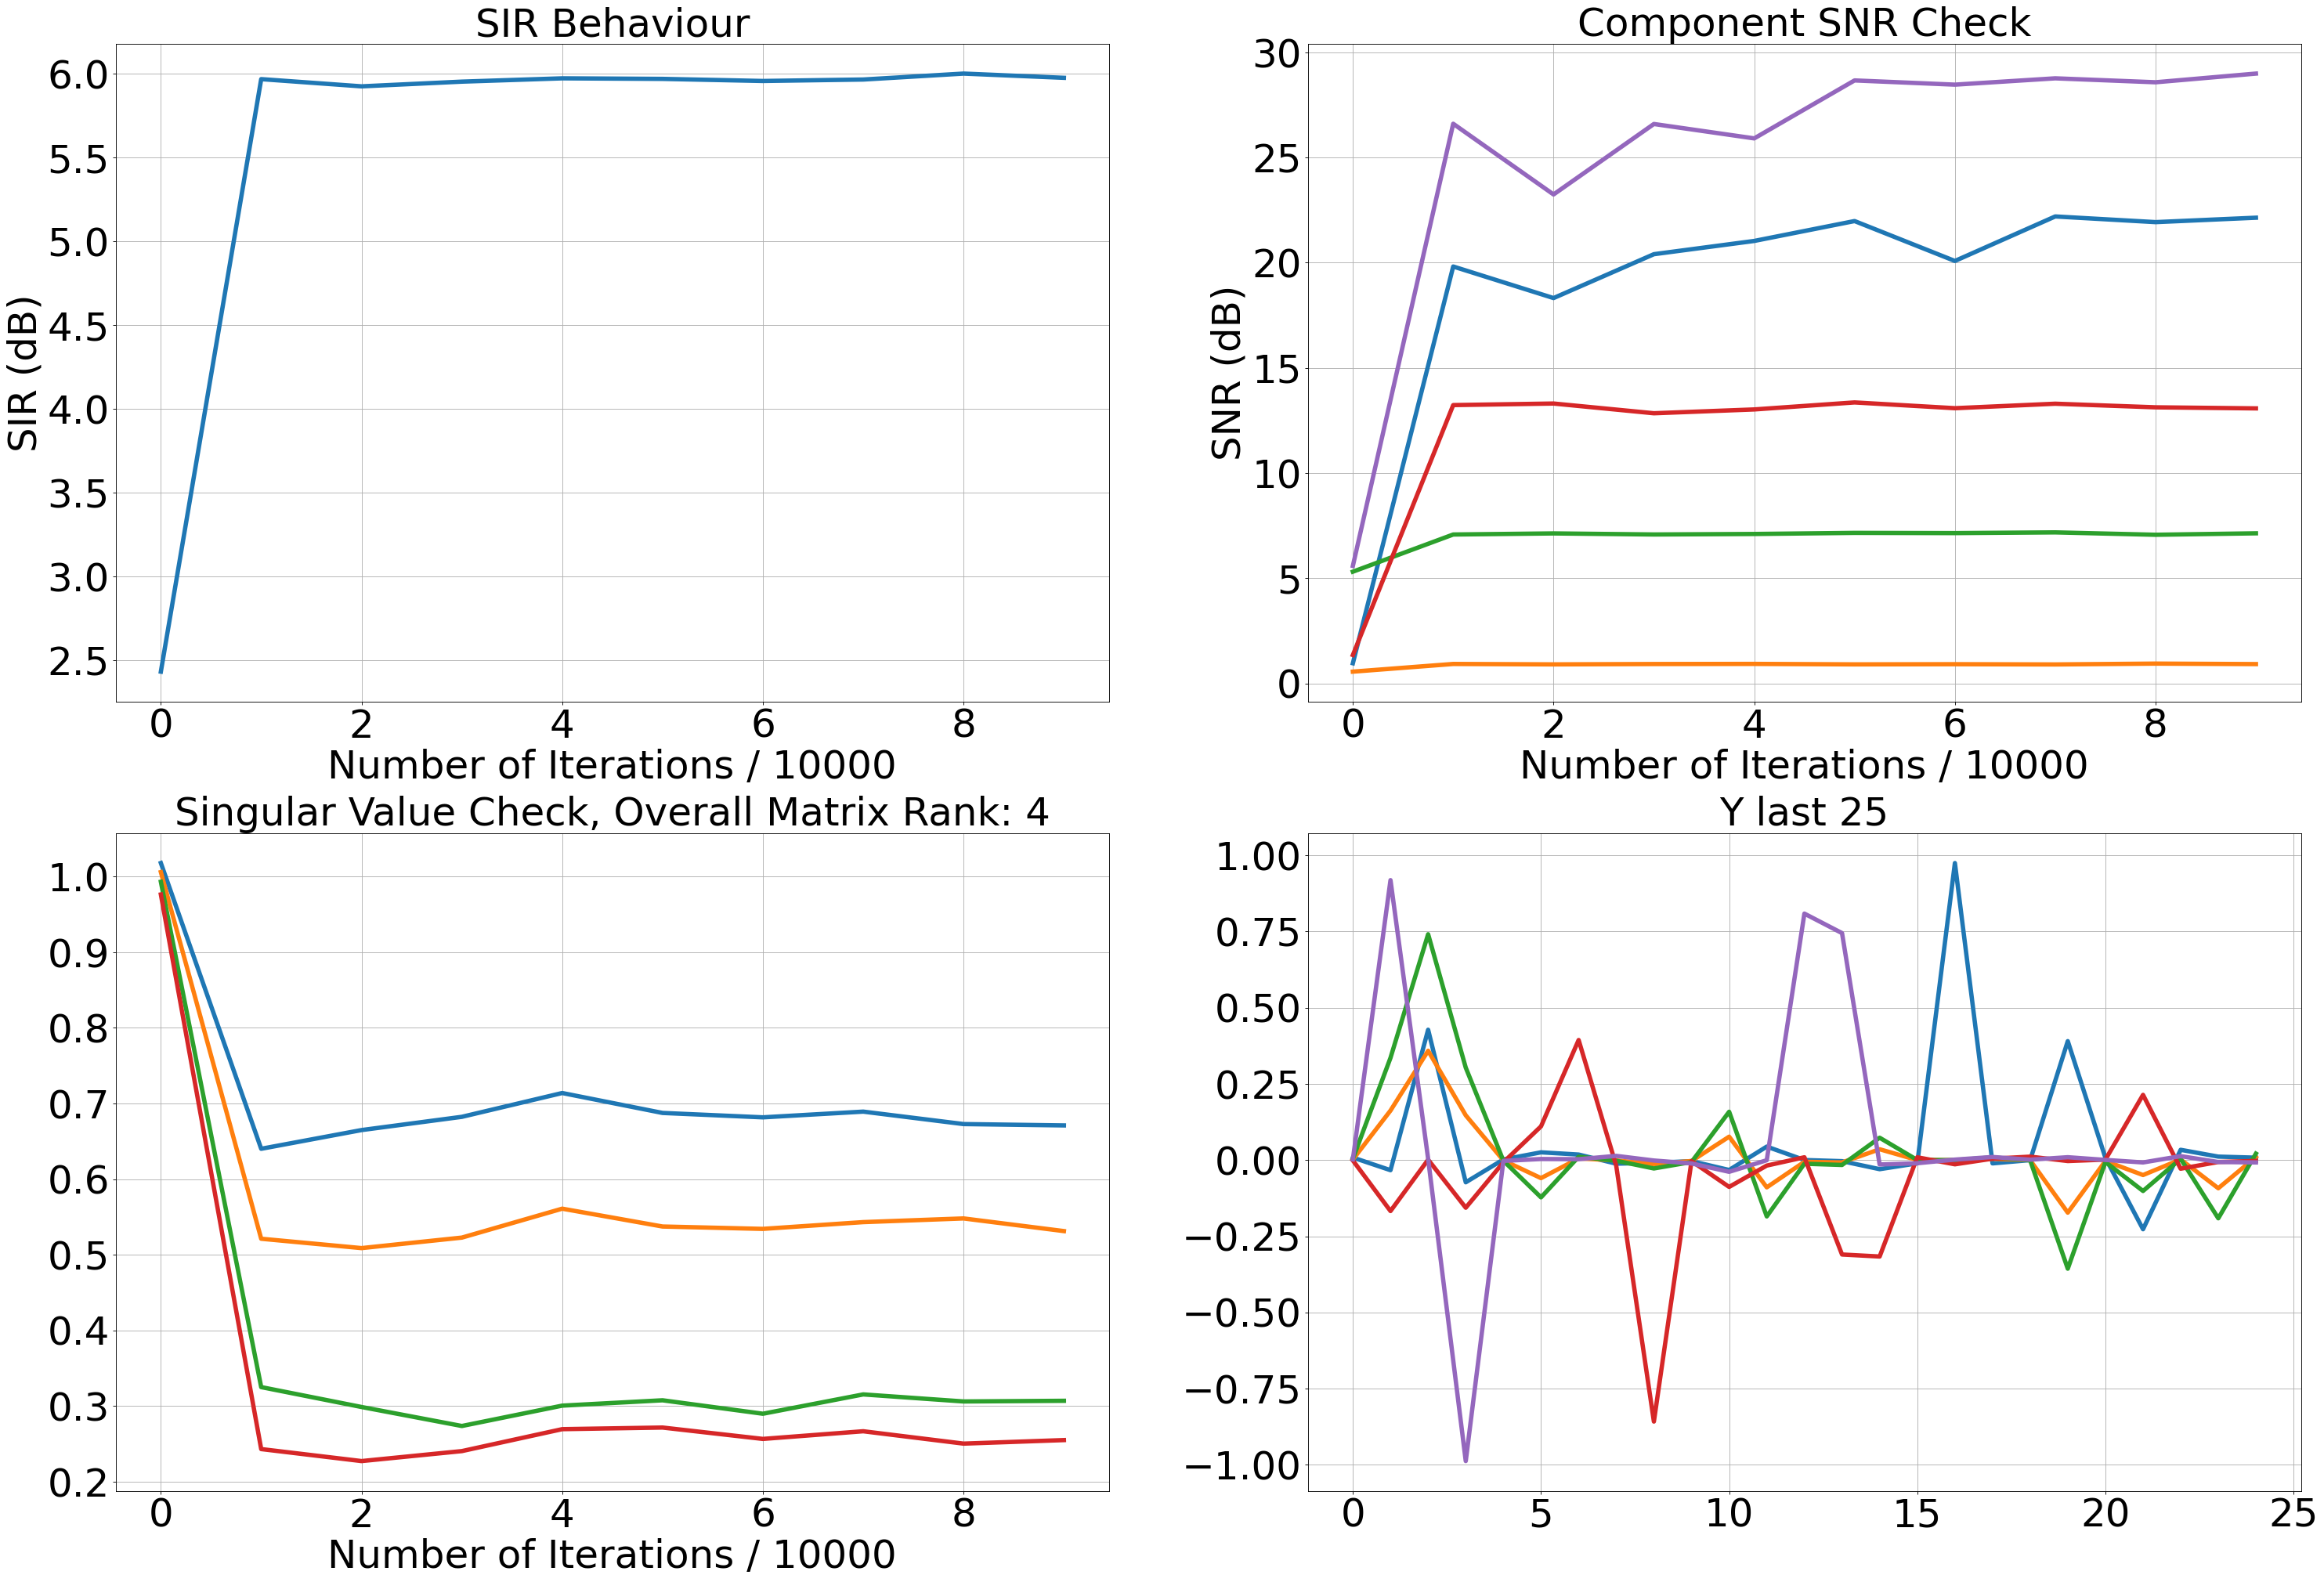

 90%|█████████ | 90474/100000 [00:12<00:01, 7567.36it/s] 

 92%|█████████▏| 91781/100000 [00:12<00:00, 8670.90it/s]

 93%|█████████▎| 93059/100000 [00:12<00:00, 9586.15it/s]

 94%|█████████▍| 94337/100000 [00:12<00:00, 10356.27it/s]

 96%|█████████▌| 95640/100000 [00:12<00:00, 11040.89it/s]

 97%|█████████▋| 96909/100000 [00:12<00:00, 11481.93it/s]

 98%|█████████▊| 98238/100000 [00:13<00:00, 11980.37it/s]

100%|█████████▉| 99505/100000 [00:13<00:00, 12174.11it/s]

100%|██████████| 100000/100000 [00:13<00:00, 7590.45it/s]

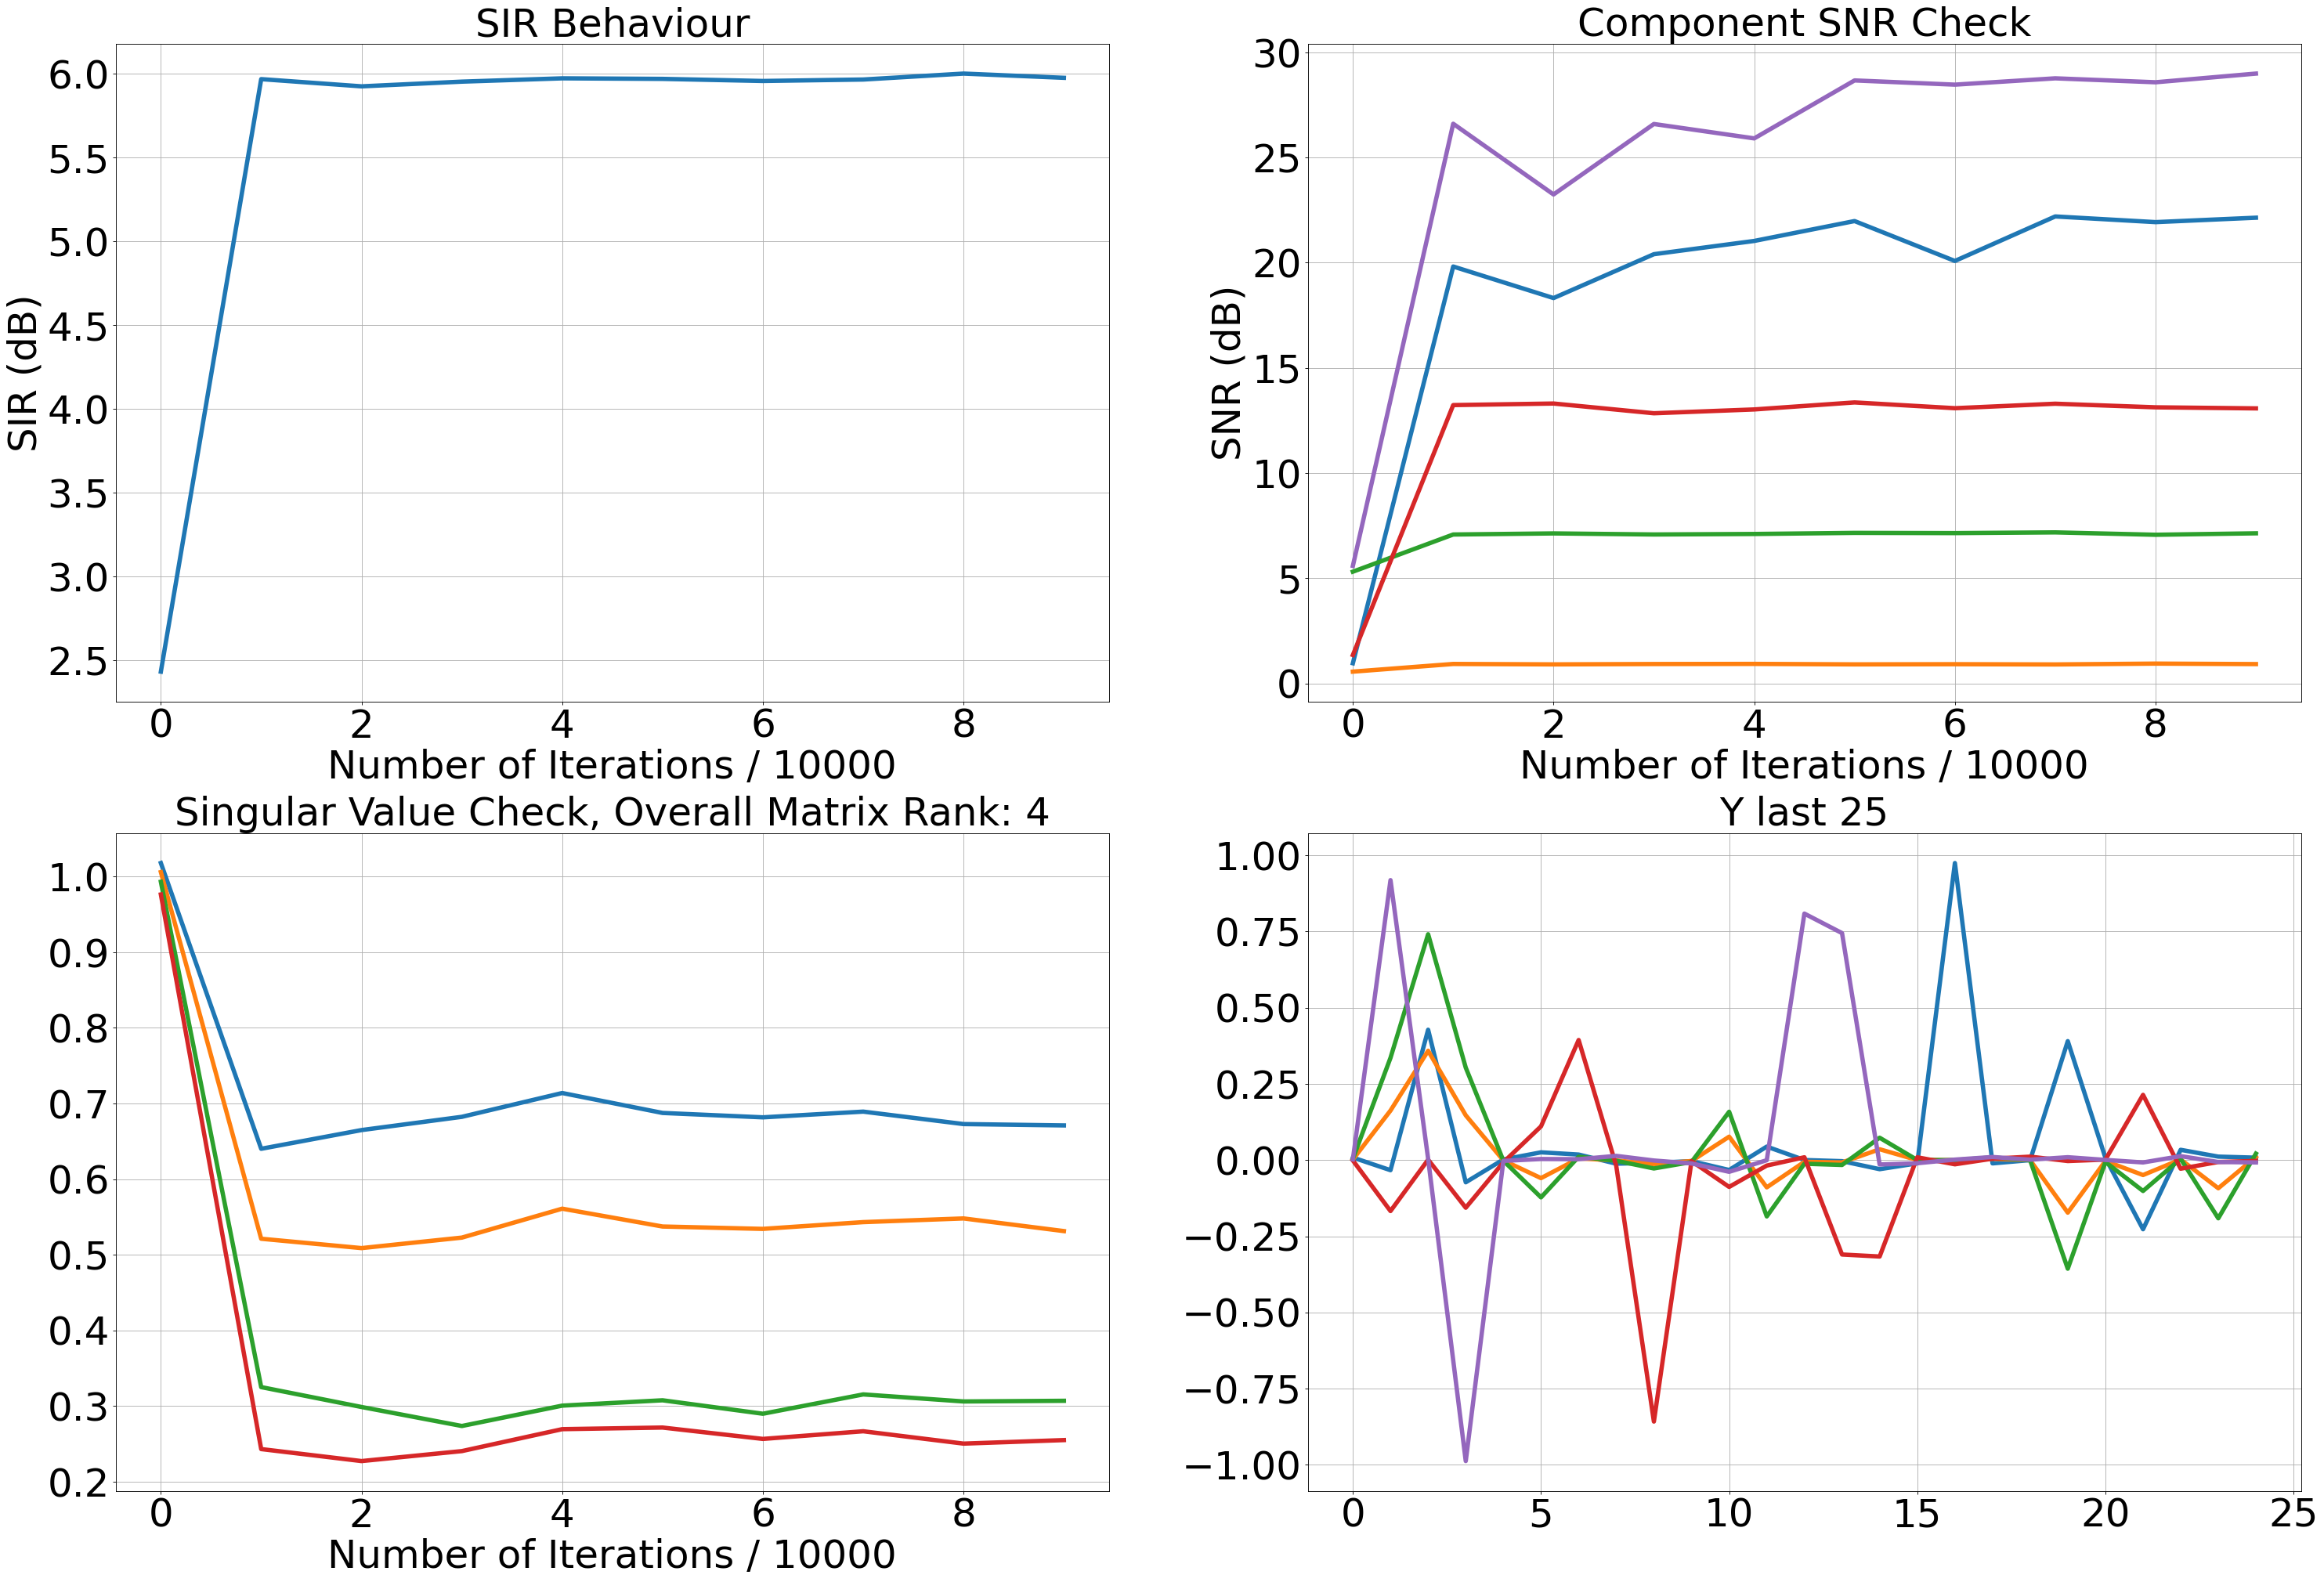

In [3]:
hyperparam_dict = {
                "n_sources" :  NumberofSources,
                "presumed_domain" : "sparse",
                ### Optimization parameters
                "lambda_lateral" : 0.99,
                "gamma_predictive" : 150,
                ### Learning rates
                "lr_W" : 5 * 1e-2,
                "neural_lr_start" : 0.05,
                "neural_lr_stop" : 1e-4,
                "stlambda_lr" : 0.5,
                "neural_dynamics_iterations" : 100,
                "neural_OUTPUT_COMP_TOL" : 1e-6,
                ### Learning rate rules and decay parameters
                "lr_W_rule" : "divide_by_index",
                "lr_W_decay_divider" : 5000,
                "neural_lr_rule" : "divide_by_loop_index",
                "neural_lr_decay_divider" : 200,
                ### Initial values for weights if provided, if not they will be initialized in the fit function
                "W" : None,
                "C_y" : None,
                "mu_y" : None,
                ### Ground truth source vectors. This part is only for debugging.
                "Sgt" : S,
                "debug_iteration_point" : 10000,
                "plot_debug_during_training" : True,
}
model = PredictiveDecorrBSS(**hyperparam_dict)
model.fit(X)

In [4]:
display_matrix(model.C_y)

<IPython.core.display.Math object>

In [5]:
display_matrix(model.mu_y.reshape(1, -1))

<IPython.core.display.Math object>

In [6]:
display_matrix(model.W)

<IPython.core.display.Math object>

In [7]:
Y_ = model.predict(X)
Y_ = model.signed_and_permutation_corrected_sources(S, Y_) # Find sign and permutation ambiguity
coef_ = ((Y_ * S).sum(axis=1) / (Y_ * Y_).sum(axis=1)).reshape(-1, 1) # Find if the extracted signals need some amplification! The networks learned weight may need amplification due to lateral connections during the neural dynamics!
Y_ = coef_ * Y_

print("Signal-to-Interference-and-Noise-Ratio (SINR): {}".format(model.ComputeSINR(Y_, S)))
print("Component Signal-to-Noise-Ratio (SNR) Values : {}\n".format(model.ComputeSNR(S, Y_)))

Signal-to-Interference-and-Noise-Ratio (SINR): 7.792922301935165
Component Signal-to-Noise-Ratio (SNR) Values : [22.02951566  0.92924797  7.1259734  13.12850431 28.41117903]



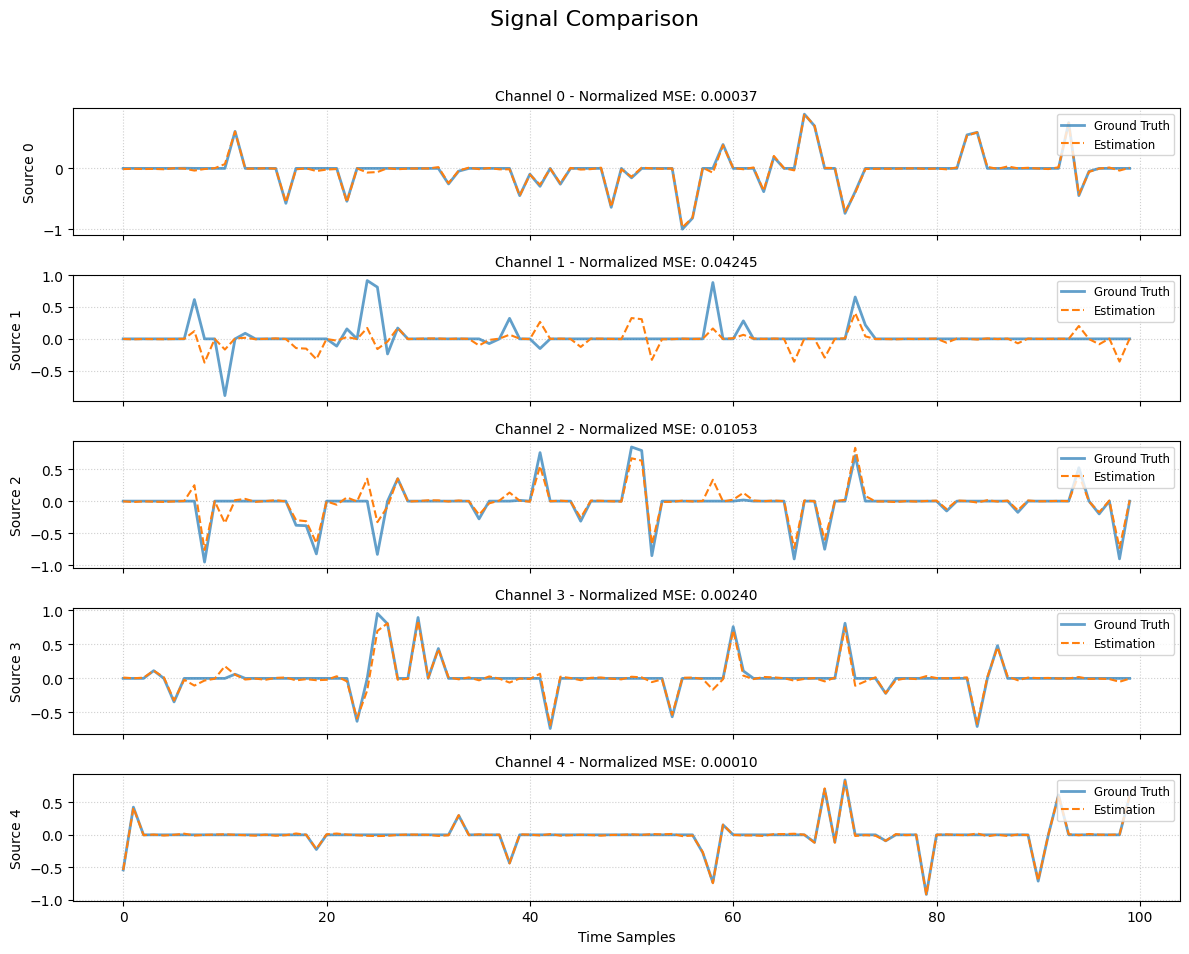

In [8]:
plot_bss_comparison(S[:, 0:100], Y_[:, 0:100])

# MMSE (Oracle) Estimator — Best Achievable Linear Reconstruction

In the underdetermined case the mixing matrix $A\in\mathbb{R}^{m\times n}$ has $m<n$, so no linear
separator can recover all $n$ sources. To see how close our network gets to the fundamental linear
limit, we compute the **clairvoyant linear MMSE (Wiener) estimator**
$W_{\mathrm{MMSE}} = R_s A^\top (A R_s A^\top + R_n)^{-1}$, which knows the mixing matrix $A$, the source
covariance $R_s$, and the noise covariance $R_n$. This is the *best possible linear estimator*; any
source it cannot recover is fundamentally unrecoverable (by a linear map) with $m$ mixtures.

In [9]:
# Clairvoyant linear MMSE (Wiener) estimator: knows A, source covariance and noise covariance.
NoisePart = X - X_noNoise
Rs = (S @ S.T) / N                                    # source covariance
Rn = (NoisePart @ NoisePart.T) / N                    # noise covariance
W_mmse = Rs @ A.T @ np.linalg.inv(A @ Rs @ A.T + Rn)  # Wiener filter (n_sources x n_mixtures)
Y_mmse = W_mmse @ X

# Evaluate with the same sign/permutation/scale correction used for the network output
Y_mmse = model.signed_and_permutation_corrected_sources(S, Y_mmse)
coef_mmse = ((Y_mmse * S).sum(axis=1) / (Y_mmse * Y_mmse).sum(axis=1)).reshape(-1, 1)
Y_mmse = coef_mmse * Y_mmse

print("MMSE (oracle) Component SNR : {}".format(model.ComputeSNR(S, Y_mmse)))
print("PEM  (ours)   Component SNR : {}".format(model.ComputeSNR(S, Y_)))

MMSE (oracle) Component SNR : [22.37886767  0.84160265  7.26021756 13.38420337 30.01066009]
PEM  (ours)   Component SNR : [22.02951566  0.92924797  7.1259734  13.12850431 28.41117903]


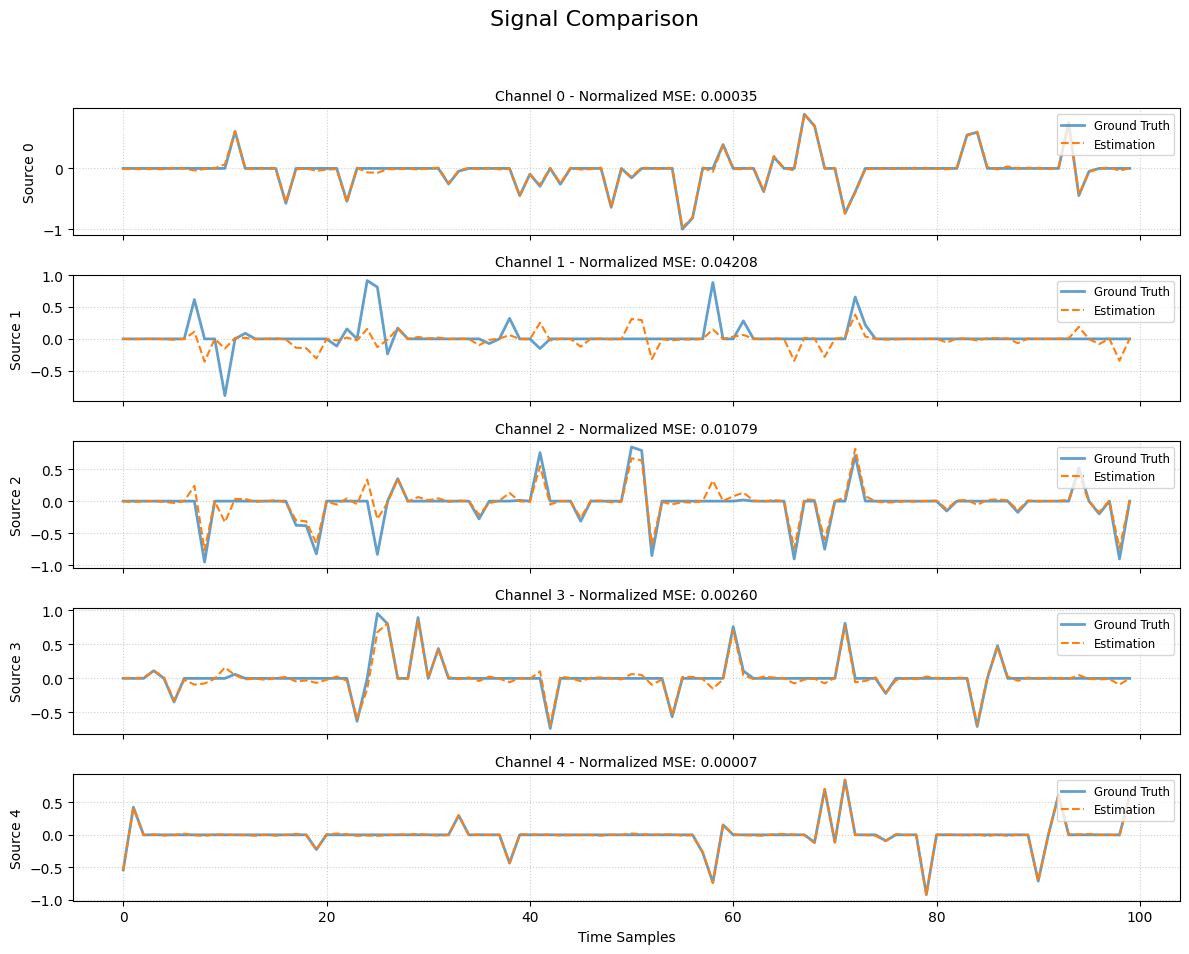

In [10]:
plot_bss_comparison(S[:, 0:100], Y_mmse[:, 0:100])